# Data Preparation - Create Keypoint Annotations

**Team Member:** Celina Binder

Since the BAMBI dataset only provides bounding box annotations, we need to create synthetic head/tail keypoint annotations for training our orientation detection model.

In [1]:
import sys
sys.path.append('..')
import json

from pathlib import Path
import numpy as np
import random
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import transforms

## Define Paths

In [2]:
DATA_DIR      = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset')
LABELS_DIR    = DATA_DIR / 'labels'
OUTPUT_DIR    = DATA_DIR / 'processed'

GT_IMAGES_DIR = DATA_DIR / 'ground_truth' / 'images'   # only used if you need to reference GT images
GT_LABELS_DIR = DATA_DIR / 'ground_truth' / 'labels'   
GT_EXPORT_OLD = Path('Users/s2410929002/CVI_2026_GroupProject/dataset/ground_truth/labels/project-1-at-2026-05-14-15-43-58c7ae18.json')
GT_EXPORT_NEW_train = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/ground_truth/labels/batch1_trainset.json')
GT_EXPORT_NEW_val = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/ground_truth/labels/batch2_valset.json')
GT_EXPORT_NEW_test = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/ground_truth/labels/batch3_testset.json')

splits = ['train', 'val', 'test']

In [14]:
import shutil

output_labels = DATA_DIR / 'processed' / 'labels_keypoints'
if output_labels.exists():
    shutil.rmtree(output_labels)
    print(f"Deleted old keypoint labels: {output_labels}")

Deleted old keypoint labels: /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints


## Load json files

In [15]:
def load_json_safe(path):
    """Load JSON with helpful error messages."""
    path = Path(path)
    if not path.exists():
        print(f"  SKIP: {path.name} not found")
        return []
    if path.stat().st_size == 0:
        print(f"  SKIP: {path.name} is empty (0 bytes)")
        return []
    try:
        with open(path, encoding='utf-8') as f:
            data = json.load(f)
        print(f"  OK: {path.name} → {len(data)} annotations")
        return data
    except json.JSONDecodeError as e:
        print(f"  ERROR: {path.name} is not valid JSON: {e}")
        return []
#load_json_safe(GT_EXPORT_OLD)

## Merging Ground Truth

In [16]:
def merge_ground_truth_files():
    print("Loading GT files...\n")
    all_data = []
    for path in [GT_EXPORT_OLD, GT_EXPORT_NEW_train, GT_EXPORT_NEW_val, GT_EXPORT_NEW_test]:
        all_data += load_json_safe(path)
    
    print(f"\nTotal GT annotations: {len(all_data)}")
    
    if len(all_data) == 0:
        print("ERROR: No annotations loaded. Check your file paths and contents.")
        return None
    
    merged_path = DATA_DIR / 'ground_truth' / 'labels' / 'all_annotations_merged.json'
    merged_path.parent.mkdir(parents=True, exist_ok=True)
    with open(merged_path, 'w') as f:
        json.dump(all_data, f, indent=2)
    print(f"Saved merged file: {merged_path}")
    return merged_path

GT_EXPORT = merge_ground_truth_files()

Loading GT files...

  SKIP: project-1-at-2026-05-14-15-43-58c7ae18.json is empty (0 bytes)
  OK: batch1_trainset.json → 87 annotations
  OK: batch2_valset.json → 38 annotations
  OK: batch3_testset.json → 40 annotations

Total GT annotations: 165
Saved merged file: /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/ground_truth/labels/all_annotations_merged.json


### Only using Ground Truth

In [17]:
# Debug: Check actual label filenames vs GT filenames

print("=== Sample GT image names from JSON ===")
with open(GT_EXPORT) as f:
    data = json.load(f)

for item in data[:5]:
    file_upload = item.get('file_upload', '')
    img_name = Path(file_upload).stem
    print(f"  JSON stem:  {img_name}")

print("\n=== Sample label filenames on disk ===")
for split in ['train', 'val', 'test']:
    label_dir = DATA_DIR / 'labels' / split
    files = list(label_dir.glob('*.txt'))[:3]
    for f in files:
        print(f"  {split}: {f.name}")

=== Sample GT image names from JSON ===


  JSON stem:  99744e9e-1_10776
  JSON stem:  514a68c0-1_10779
  JSON stem:  d99032c6-1_10780
  JSON stem:  d73d23da-1_10782
  JSON stem:  b9748df0-1_10800

=== Sample label filenames on disk ===
  train: 0_8082.txt
  train: 0_8083.txt
  train: 0_8084.txt
  val: 10_2324.txt
  val: 10_2338.txt
  val: 10_2339.txt
  test: 152_14253.txt
  test: 152_14273.txt
  test: 152_14293.txt


In [18]:
## Process Ground Truth with Keypoint Pairing

def parse_keypoint_pairs(results):
    """
    Extract matched (Head, Tail) pairs from Label Studio results.
    Pairs each Head with its nearest Tail — handles multiple animals per image.
    """
    heads, tails = [], []
    for r in results:
        label = r['value']['keypointlabels'][0]
        x = r['value']['x'] / 100.0
        y = r['value']['y'] / 100.0
        if label == 'Head':
            heads.append((x, y))
        elif label == 'Tail':
            tails.append((x, y))

    if not heads or not tails:
        return []

    pairs = []
    used = set()
    for head in heads:
        best_dist, best_idx = float('inf'), None
        for i, tail in enumerate(tails):
            if i in used:
                continue
            d = np.sqrt((head[0]-tail[0])**2 + (head[1]-tail[1])**2)
            if d < best_dist:
                best_dist, best_idx = d, i
        if best_idx is not None:
            pairs.append({'head': head, 'tail': tails[best_idx]})
            used.add(best_idx)
    return pairs


def match_pairs_to_bboxes(pairs, bbox_lines):
    results = []
    used_lines = set()

    for pair in pairs:
        mid_x = (pair['head'][0] + pair['tail'][0]) / 2
        mid_y = (pair['head'][1] + pair['tail'][1]) / 2

        best_dist, best_idx, best_line = float('inf'), None, None
        for i, line in enumerate(bbox_lines):
            if i in used_lines:
                continue
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cx, cy = float(parts[1]), float(parts[2])
            bw, bh = float(parts[3]), float(parts[4])

            # Only match if midpoint falls within 2x the bbox area
            if abs(mid_x - cx) > bw and abs(mid_y - cy) > bh:
                continue

            d = np.sqrt((mid_x - cx)**2 + (mid_y - cy)**2)
            if d < best_dist:
                best_dist, best_idx, best_line = d, i, line.strip()

        if best_line:
            results.append({
                'bbox_line': best_line,
                'head': pair['head'],
                'tail': pair['tail']
            })
            used_lines.add(best_idx)

    return results


def process_real_ground_truth_with_split():
    if GT_EXPORT is None or not GT_EXPORT.exists():
        print("ERROR: No merged GT file found. Run merge step first.")
        return 0, 0, 0

    with open(GT_EXPORT) as f:
        data = json.load(f)
    print(f"Loaded {len(data)} total GT annotations\n")

    valid_items = []
    skipped = 0

    for item in data:
        file_upload = item.get('data', {}).get('img', '')

        if not file_upload:
            print(f"  SKIP item id={item.get('id')} - no image path")
            continue

        raw_stem = Path(file_upload).stem

        # Remove LS upload prefix/hash
        # Example:
        #   "141d1290-6_4645" -> "6_4645"
        if '-' in raw_stem:
            img_name = raw_stem.split('-', 1)[-1]
        else:
            img_name = raw_stem

        if not img_name:
            print(f"  SKIP bad filename: {file_upload}")
            continue

        for ann in item.get('annotations', []):
            pairs = parse_keypoint_pairs(ann.get('result', []))
            if not pairs:
                print(f"  SKIP {img_name}: no valid head/tail pairs")
                skipped += 1
                continue
            for pair in pairs:
                valid_items.append({
                    'img_name': img_name,
                    'head': pair['head'],
                    'tail': pair['tail']
                })

    print(f"Valid (img, head, tail) entries: {len(valid_items)}  |  Skipped: {skipped}\n")

    # Shuffle and split 70/15/15
    import random
    random.shuffle(valid_items)
    n = len(valid_items)
    t = int(n * 0.70)
    v = int(n * 0.15)
    splits_data = {
        'train': valid_items[:t],
        'val':   valid_items[t:t+v],
        'test':  valid_items[t+v:]
    }
    for s, items in splits_data.items():
        print(f"  {s:5}: {len(items)} entries")

    counts = {'train': 0, 'val': 0, 'test': 0}

    for split, items in splits_data.items():
        for item in items:
            img_name = item['img_name']
            head     = item['head']
            tail     = item['tail']

            # Search for the label file across all original splits
            orig_label_path = None
            for src_split in ['train', 'val', 'test']:
                candidate = DATA_DIR / 'labels' / src_split / f"{img_name}.txt"
                if candidate.exists():
                    orig_label_path = candidate
                    break

            if orig_label_path is None:
                print(f"  WARN: no label file found for {img_name}")
                continue

            with open(orig_label_path) as f:
                bbox_lines = f.readlines()

            matched = match_pairs_to_bboxes([{'head': head, 'tail': tail}], bbox_lines)

            if not matched:
                print(f"  WARN: could not match keypoints to bbox for {img_name}")
                continue

            output_path = OUTPUT_DIR / 'labels_keypoints' / split / f"{img_name}.txt"
            output_path.parent.mkdir(parents=True, exist_ok=True)

            # Append mode so multiple animals in same image accumulate
            with open(output_path, 'a') as f:
                for m in matched:
                    h, t_ = m['head'], m['tail']
                    f.write(
                        f"{m['bbox_line']} "
                        f"{h[0]:.6f} {h[1]:.6f} 1 "
                        f"{t_[0]:.6f} {t_[1]:.6f} 1\n"
                    )
            counts[split] += 1

    print(f"\nCreated keypoint labels:")
    for s, c in counts.items():
        print(f"  {s:5}: {c}")

    return counts['train'], counts['val'], counts['test']


train_count, val_count, test_count = process_real_ground_truth_with_split()

Loaded 165 total GT annotations

Valid (img, head, tail) entries: 564  |  Skipped: 0

  train: 394 entries
  val  : 84 entries
  test : 86 entries


  WARN: could not match keypoints to bbox for 55_6878
  WARN: could not match keypoints to bbox for 115_5697
  WARN: could not match keypoints to bbox for 55_9955
  WARN: could not match keypoints to bbox for 284_9406
  WARN: could not match keypoints to bbox for 55_6878
  WARN: could not match keypoints to bbox for 284_9336
  WARN: could not match keypoints to bbox for 115_5817
  WARN: could not match keypoints to bbox for 284_9347
  WARN: could not match keypoints to bbox for 229_993
  WARN: could not match keypoints to bbox for 1_10905
  WARN: could not match keypoints to bbox for 115_6007
  WARN: could not match keypoints to bbox for 284_9336
  WARN: could not match keypoints to bbox for 284_9374
  WARN: could not match keypoints to bbox for 284_9662
  WARN: could not match keypoints to bbox for 229_986
  WARN: could not match keypoints to bbox for 284_9347
  WARN: could not match keypoints to bbox for 115_5727
  WARN: could not match keypoints to bbox for 284_9336
  WARN: could no

## Visualize Sample with Keypoints

Visualizing from 'train' split: 10_2324


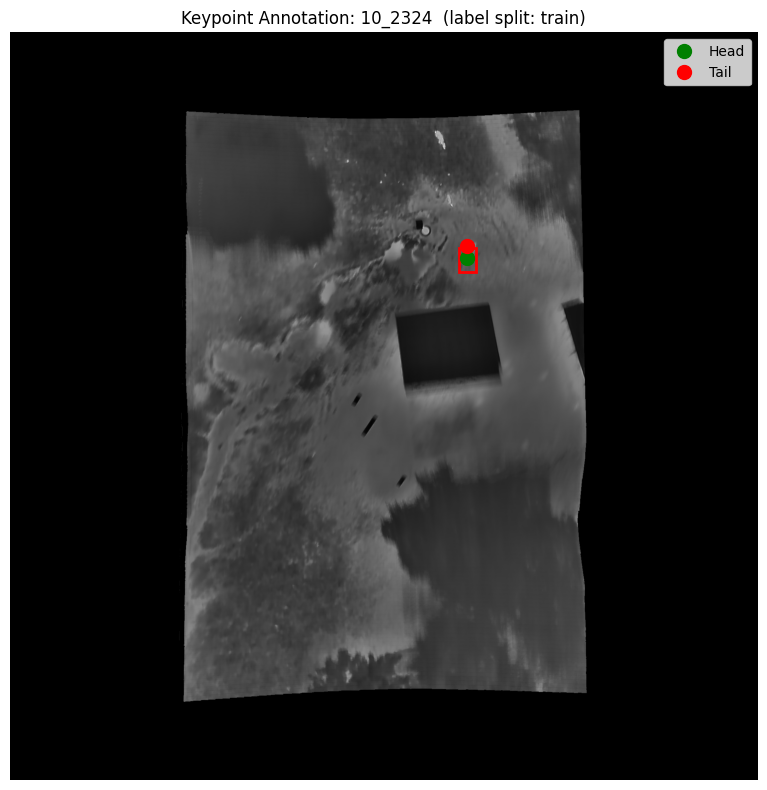

Visualizing from 'val' split: 115_5727


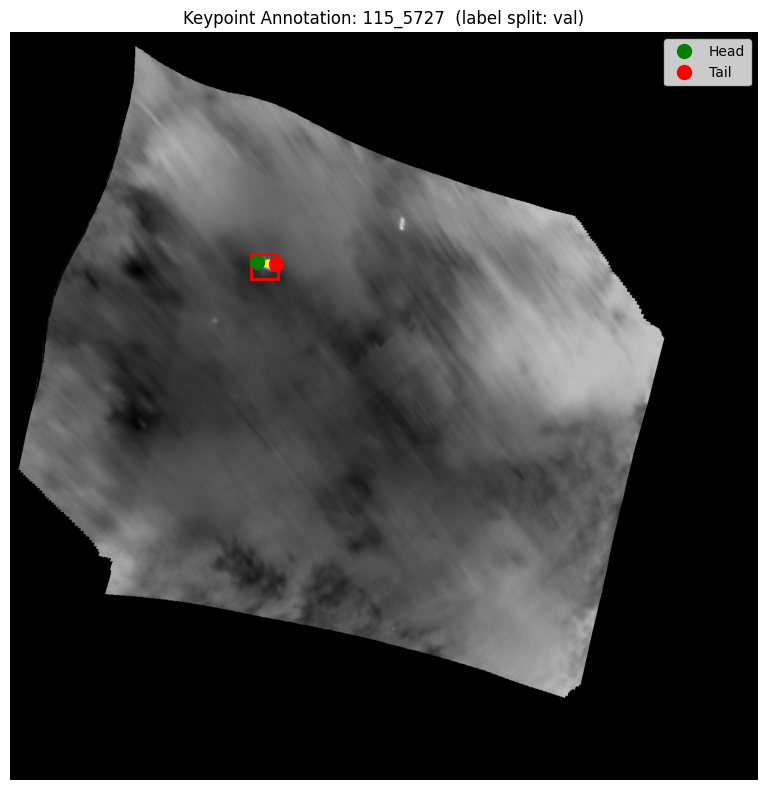

Visualizing from 'test' split: 115_5607


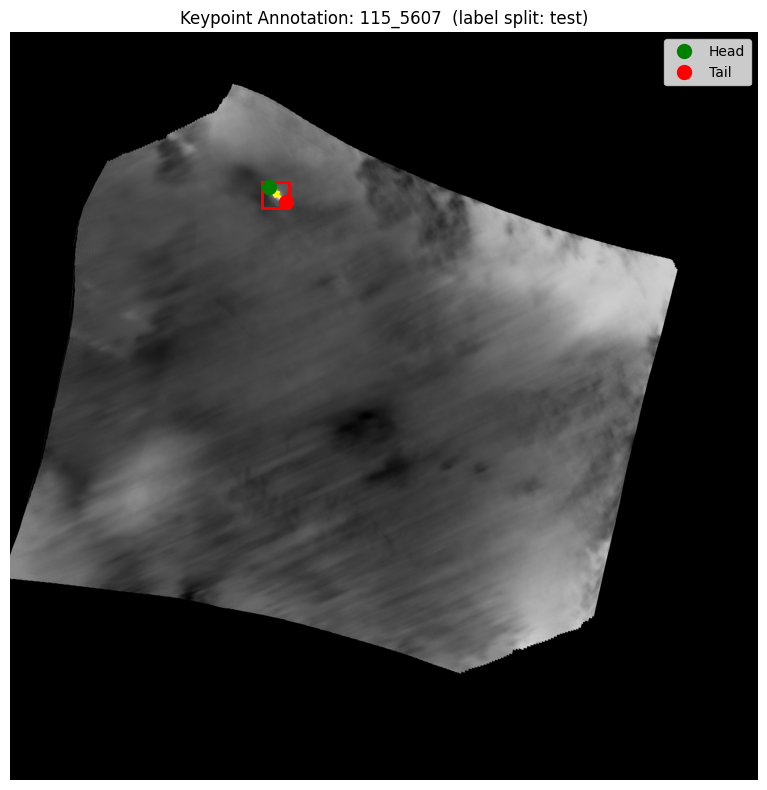

In [19]:
## Visualize Sample with Keypoints

def visualize_keypoints(img_name, kp_split='test'):
    """Visualize image with keypoints. Searches all image splits for the source image."""
    
    # Find the keypoint label in our output directory
    kp_label = OUTPUT_DIR / 'labels_keypoints' / kp_split / f"{img_name}.txt"
    if not kp_label.exists():
        print(f"Keypoint label not found: {kp_label}")
        return
    
    # Search for the image across all original BAMBI splits
    img_path = None
    for split in ['train', 'val', 'test']:
        candidate = DATA_DIR / 'images' / split / f"{img_name}.jpg"
        if candidate.exists():
            img_path = candidate
            break
    
    if img_path is None:
        print(f"Image not found in any split for: {img_name}")
        print(f"   Searched: {DATA_DIR / 'images' / '*' / (img_name + '.jpg')}")
        return
    
    img = Image.open(img_path)
    width, height = img.size
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img)
    
    handles = {}  # avoid duplicate legend entries
    
    with open(kp_label, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 11:
                print(f"Skipping malformed row ({len(parts)} values): {line.strip()}")
                continue

            cx     = float(parts[1]) * width
            cy     = float(parts[2]) * height
            w      = float(parts[3]) * width
            h      = float(parts[4]) * height
            head_x = float(parts[5]) * width
            head_y = float(parts[6]) * height
            head_v = int(parts[7])
            tail_x = float(parts[8]) * width
            tail_y = float(parts[9]) * height
            tail_v = int(parts[10])

            rect = plt.Rectangle(
                (cx - w/2, cy - h/2), w, h,
                fill=False, edgecolor='red', linewidth=2
            )
            ax.add_patch(rect)

            if head_v == 1:
                h_pt = ax.plot(head_x, head_y, 'go', markersize=10, zorder=5)[0]
                t_pt = ax.plot(tail_x, tail_y, 'ro', markersize=10, zorder=5)[0]
                ax.annotate('', xy=(head_x, head_y), xytext=(tail_x, tail_y),
                            arrowprops=dict(arrowstyle='->', color='yellow', lw=2))
                handles['Head'] = h_pt
                handles['Tail'] = t_pt

    if handles:
        ax.legend(handles=list(handles.values()),
                  labels=list(handles.keys()),
                  loc='upper right')

    ax.axis('off')
    ax.set_title(f"Keypoint Annotation: {img_name}  (label split: {kp_split})")
    plt.tight_layout()
    plt.show()


# Show samples from each output split
for kp_split in ['train', 'val', 'test']:
    split_dir = OUTPUT_DIR / 'labels_keypoints' / kp_split
    if not split_dir.exists():
        continue
    files = list(split_dir.glob('*.txt'))
    if not files:
        continue
    img_stem = files[0].stem
    print(f"Visualizing from '{kp_split}' split: {img_stem}")
    visualize_keypoints(img_stem, kp_split)

## Output Format

The keypoint labels follow YOLO keypoint format:
```
class_id x_center y_center width height head_x head_y head_visible tail_x tail_y tail_visible
```

- All coordinates are normalized [0, 1]
- Visibility: 1 = visible, 0 = not visible